## Forecasting UK House Price Index Growth Using Macroeconomic Indicators
### Notebook 2

Source
https://www.gov.uk/government/statistical-data-sets/uk-house-price-index-data-downloads-december-

Information on dataset
https://www.gov.uk/government/publications/about-the-uk-house-price-index/about-the-uk-house-price-index#data-tables

5. Feature Engineering
6. Prep for training
7. Train models
8. Evaluate


In [2]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import seaborn as sns

### Import cleaned dataset

In [4]:
filepath = "../data/full_data_clean.csv"

#### Create a dataframe from csv

In [6]:
data = pd.read_csv(filepath)

### Initial data inspection

#### Examine data

In [9]:
print(f"Data shape:{data.shape}")
data.head()

Data shape:(113052, 15)


,Unnamed: 0,Date,RegionName,AreaCode,AveragePrice,Index,1m%Change,12m%Change,SalesVolume,Region,norm_index,YoYRolling3,IndexRolling12,YoYRollingStd6,CPIH
0,0,2004-01-01,Aberdeenshire,S12000034,84638,41.1,NaN,NaN,388.0,Scotland,100.000000,NaN,NaN,NaN,77.001
1,1,2004-02-01,Aberdeenshire,S12000034,84623,41.1,0.0,NaN,326.0,Scotland,100.000000,NaN,NaN,NaN,77.180
2,2,2004-03-01,Aberdeenshire,S12000034,86536,42.1,2.3,NaN,453.0,Scotland,102.433090,NaN,NaN,NaN,77.290
3,3,2004-04-01,Aberdeenshire,S12000034,87373,42.5,1.0,NaN,571.0,Scotland,103.406326,NaN,NaN,NaN,77.647
4,4,2004-05-01,Aberdeenshire,S12000034,89493,43.5,2.4,NaN,502.0,Scotland,105.839416,NaN,NaN,NaN,77.871


In [10]:
data = data.drop(columns=['Unnamed: 0'])
data['Date'] = pd.to_datetime(
    data['Date'].astype(str).str.strip(),
    format='%Y-%m-%d',
    errors='raise'
)

## 5. Feature Engineering
Add:
Lag 1 month, 3 month, 12 month, region dummies
Inflation, unemployment, interest rates

momentum -> lagged growth, trend -> rolling mean, risk-> rolling std, demand -> sales volume, structure -> region dummies, seasonality-> month/quarter


In [12]:
data.head()

,Date,RegionName,AreaCode,AveragePrice,Index,1m%Change,12m%Change,SalesVolume,Region,norm_index,YoYRolling3,IndexRolling12,YoYRollingStd6,CPIH
0,2004-01-01,Aberdeenshire,S12000034,84638,41.1,NaN,NaN,388.0,Scotland,100.000000,NaN,NaN,NaN,77.001
1,2004-02-01,Aberdeenshire,S12000034,84623,41.1,0.0,NaN,326.0,Scotland,100.000000,NaN,NaN,NaN,77.180
2,2004-03-01,Aberdeenshire,S12000034,86536,42.1,2.3,NaN,453.0,Scotland,102.433090,NaN,NaN,NaN,77.290
3,2004-04-01,Aberdeenshire,S12000034,87373,42.5,1.0,NaN,571.0,Scotland,103.406326,NaN,NaN,NaN,77.647
4,2004-05-01,Aberdeenshire,S12000034,89493,43.5,2.4,NaN,502.0,Scotland,105.839416,NaN,NaN,NaN,77.871


#### Add index growth lags

In [14]:
data['lag1_12mGrowth'] = (
    data.groupby('RegionName')['12m%Change']
        .shift(1)
)
data['lag3_12mGrowth'] = (
    data.groupby('RegionName')['12m%Change']
        .shift(3)
)
data['lag12_12mGrowth'] = (
    data.groupby('RegionName')['12m%Change']
        .shift(12)
)


#### Add sales volume lags and growth

In [16]:
data['lag_1_sales_vol'] = (
    data.groupby('RegionName')['SalesVolume']
        .shift(1)
)
data['lag_6_sales_vol'] = (
    data.groupby('RegionName')['SalesVolume']
        .shift(6)
)
data["6mChange_sales_vol"] = (
    data.groupby("RegionName")["SalesVolume"]
        .pct_change(6)
)

#### Add region dummies
~One-hot encode the categorical variable region.~

In [18]:
#dummies = pd.get_dummies(data['Region'],drop_first=True)
#data = pd.concat([data,dummies],axis=1)

### 6. Prep for training

In [20]:
# drop columns not needed
data = data.drop(columns=['RegionName','AreaCode','AveragePrice','Index'])

#### Check for missing values

In [22]:
missing_rows = data[data.isna().any(axis=1)]
missing_rows.sort_values(by='Date')

,Date,1m%Change,12m%Change,SalesVolume,Region,norm_index,YoYRolling3,IndexRolling12,YoYRollingStd6,CPIH,lag1_12mGrowth,lag3_12mGrowth,lag12_12mGrowth,lag_1_sales_vol,lag_6_sales_vol,6mChange_sales_vol
0,2004-01-01,NaN,NaN,388.0,Scotland,100.000000,NaN,NaN,NaN,77.001,NaN,NaN,NaN,NaN,NaN,NaN
99952,2004-01-01,-0.3,6.3,184.0,South East England,100.000000,NaN,NaN,NaN,77.001,NaN,NaN,NaN,NaN,NaN,NaN
57282,2004-01-01,0.6,10.5,368.0,East of England,100.000000,NaN,NaN,NaN,77.001,NaN,NaN,NaN,NaN,NaN,NaN
10956,2004-01-01,2.4,6.4,179.0,East of England,100.000000,NaN,NaN,NaN,77.001,NaN,NaN,NaN,NaN,NaN,NaN
57020,2004-01-01,0.9,5.6,12767.0,London,100.000000,NaN,NaN,NaN,77.001,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1833,2006-12-01,14.4,49.3,416.0,Northern Ireland,169.325153,45.433333,137.295501,8.608833,82.605,49.3,37.7,NaN,416.0,411.0,0.012165
1321,2006-12-01,12.8,38.6,400.0,Northern Ireland,151.911765,35.033333,126.323529,8.432655,82.605,38.6,27.9,NaN,400.0,379.0,0.055409
56531,2006-12-01,12.4,39.9,269.0,Northern Ireland,162.204724,36.533333,133.700787,6.557261,82.605,39.9,29.8,NaN,269.0,288.0,-0.065972
61223,2006-12-01,12.4,38.0,256.0,Northern Ireland,154.765507,33.566667,128.895613,7.424733,82.605,38.0,24.7,NaN,256.0,303.0,-0.155116


In [23]:
data = data[data['Date']>'2007-01-01']
data.isna().sum()

Date                  0
1m%Change             0
12m%Change            0
SalesVolume           0
Region                0
norm_index            0
YoYRolling3           0
IndexRolling12        0
YoYRollingStd6        0
CPIH                  0
lag1_12mGrowth        0
lag3_12mGrowth        0
lag12_12mGrowth       0
lag_1_sales_vol       0
lag_6_sales_vol       0
6mChange_sales_vol    0
dtype: int64

So we'll start the dataset after June 2006.

In [25]:
data = data.sort_values(by='Date')
data.head()

,Date,1m%Change,12m%Change,SalesVolume,Region,norm_index,YoYRolling3,IndexRolling12,YoYRollingStd6,CPIH,lag1_12mGrowth,lag3_12mGrowth,lag12_12mGrowth,lag_1_sales_vol,lag_6_sales_vol,6mChange_sales_vol
37,2007-02-01,-0.1,32.5,323.0,Scotland,177.858881,24.033333,159.306569,4.419804,82.426,30.6,21.3,12.2,361.0,587.0,-0.449744
76147,2007-02-01,0.8,8.7,411.0,London,119.724771,8.600000,113.646789,0.720185,82.426,8.6,8.7,4.7,377.0,593.0,-0.306914
75885,2007-02-01,1.7,13.2,259.0,South East England,124.197002,9.566667,115.935046,2.655309,82.426,9.7,9.5,1.4,319.0,381.0,-0.320210
3407,2007-02-01,1.1,10.2,494.0,London,119.257541,7.566667,112.857695,1.379009,82.426,8.6,6.1,1.4,505.0,696.0,-0.290230
75623,2007-02-01,2.3,9.1,208.0,North West England,151.254480,7.800000,144.698327,1.375136,82.426,6.7,8.2,8.2,200.0,325.0,-0.360000


#### Split data

In [27]:

split_idx = int(len(data)*0.8)
train = data.iloc[:split_idx]
test = data.iloc[split_idx:]

X_train = train.drop(columns=['12m%Change'])
y_train = train['12m%Change']

X_test = test.drop(columns=['12m%Change'])
y_test = test['12m%Change']


In [28]:
print(data.shape)

(97200, 16)


#### Preprocessing

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


num_cols = X_train.select_dtypes(include=['int64','float64']).columns
cat_cols = X_train.select_dtypes(include='str').columns


numeric_transformer = Pipeline(steps=[("imputer",SimpleImputer(strategy='median'))])
categorical_transformer = Pipeline(steps=[("imputer",SimpleImputer(strategy='most_frequent')),("onehot",OneHotEncoder(drop='first',handle_unknown='ignore')) ])

preprocessor = ColumnTransformer(transformers=[("num",numeric_transformer,num_cols),("cat",categorical_transformer,cat_cols)])

    

#### Compute a baseline
Use mean as a baseline to compare to trained models.

In [32]:
base_mean = y_train.mean() # computes a scalar

# create "predictions" array from base mean
y_preds_base = np.full(len(y_test),base_mean)

Use a naive forecast as a baseline.

In [61]:
y_preds_naive = X_test['lag1_12mGrowth']

### 7. Train models

#### Train a base model
Use linear regression as a base model, a step up from mean as a baseline.

In [35]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()

reg_lr = Pipeline(steps=[("preprocessor",preprocessor),("model",model_lr)])
reg_lr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

#### Train another model

In [37]:
X_train_transformed = preprocessor.fit_transform(X_train)
print(X_train_transformed.shape)
print(type(X_train_transformed))

(77760, 25)
<class 'numpy.ndarray'>


In [38]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=200,random_state=42)

reg_rf = Pipeline(steps=[("preprocessor",preprocessor),("model",model_rf)])
reg_rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

### 8. Evaluate models

In [65]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error

# base mean
mae_base = mean_absolute_error(y_test, y_preds_base)
rmse_base = root_mean_squared_error(y_test, y_preds_base)
print(f"Base (mean), Mean Absolute Error:{mae_base}")
print(f"Base (mean), Root Mean Squared Error:{rmse_base}\n")

# base naive
mae_naive = mean_absolute_error(y_test, y_preds_naive)
rmse_naive = root_mean_squared_error(y_test, y_preds_naive)
print(f"Base (naive), Mean Absolute Error:{mae_naive}")
print(f"Base (naive), Root Mean Squared Error:{rmse_naive}\n")

# linear regression model
preds_lr = reg_lr.predict(X_test)
mae_lr = mean_absolute_error(y_test, preds_lr)
rmse_lr = root_mean_squared_error(y_test, preds_lr)
print(f"Linear Regression, Mean Absolute Error:{mae_lr}")
print(f"Linear Regression, Root Mean Squared Error:{rmse_lr}\n")

# random forest model
preds_rf = reg_rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, preds_rf)
rmse_rf = root_mean_squared_error(y_test, preds_rf)
print(f"Random Forest, Mean Absolute Error:{mae_rf}")
print(f"Random Forest, Root Mean Squared Error:{rmse_rf}")


Base (mean), Mean Absolute Error:4.222845486508028
Base (mean), Root Mean Squared Error:5.247096322689793

Base (naive), Mean Absolute Error:1.3450925925925925
Base (naive), Root Mean Squared Error:1.9063468824466319

Linear Regression, Mean Absolute Error:0.9918530876302649
Linear Regression, Root Mean Squared Error:1.3700469956611416

Random Forest, Mean Absolute Error:1.0351101851851852
Random Forest, Root Mean Squared Error:1.4461537669076385


### Model Diagnostics

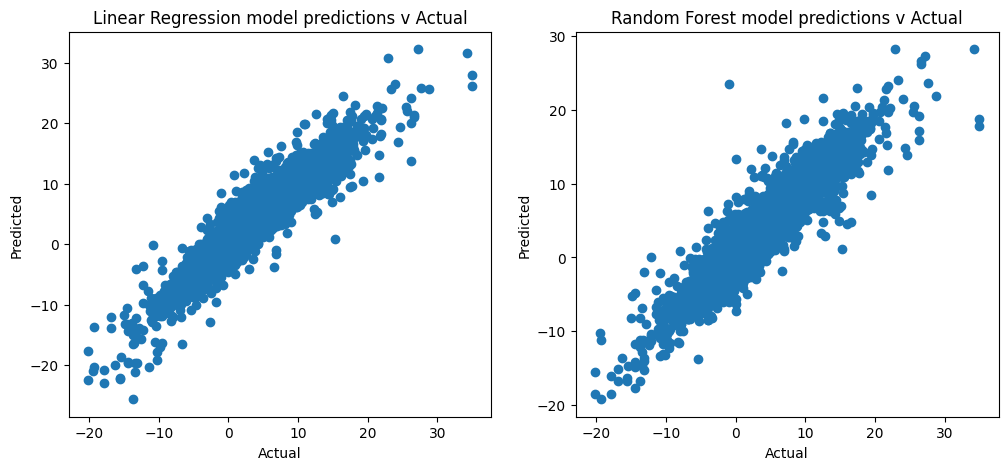

In [42]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12,5))

ax1.scatter(y_test, preds_lr)
ax1.set_xlabel("Actual")
ax1.set_ylabel("Predicted")
ax1.set_title("Linear Regression model predictions v Actual")

ax2.scatter(y_test, preds_rf)
ax2.set_xlabel("Actual")
ax2.set_ylabel("Predicted")
ax2.set_title("Random Forest model predictions v Actual")

plt.show()

In [43]:
print(f"Standard deviation for actuals: {y_test.std()}")
print(f"Standard deviation for Linear Regression model predictions: {preds_lr.std()}")
print(f"Standard deviation for Random Forest model predictions: {preds_rf.std()}")

Standard deviation for actuals: 5.239685048445442
Standard deviation for Linear Regression model predictions: 5.364009368691586
Standard deviation for Random Forest model predictions: 5.022421523500592


### Analyse Features
Examine the coefficients from the linear regression model.

In [45]:
# Get feature names after preprocessing
feature_names = reg_lr.named_steps["preprocessor"].get_feature_names_out()

# Get coefficients from linear regression
coefficients = reg_lr.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
}).sort_values("coefficient", key=abs, ascending=False)

coef_df.head(20)

,feature,coefficient
24,cat__Region_none,-0.803995
7,num__lag1_12mGrowth,0.671800
0,num__1m%Change,0.540464
12,num__6mChange_sales_vol,-0.429305
4,num__IndexRolling12,-0.211913
2,num__norm_index,0.211278
3,num__YoYRolling3,0.198925
15,cat__Region_North East England,-0.117672
16,cat__Region_North West England,-0.102195
18,cat__Region_Scotland,-0.100771


Examine features from random forest model

In [54]:
feature_names = reg_rf.named_steps["preprocessor"].get_feature_names_out()

rf = reg_rf.named_steps["model"]
importances = rf.feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print(feat_imp)

num__lag1_12mGrowth                     0.895207
num__1m%Change                          0.052098
num__lag12_12mGrowth                    0.009034
num__CPIH                               0.006339
num__YoYRollingStd6                     0.005160
num__YoYRolling3                        0.004625
num__lag3_12mGrowth                     0.004175
num__SalesVolume                        0.003648
num__lag_6_sales_vol                    0.003615
num__6mChange_sales_vol                 0.003604
num__lag_1_sales_vol                    0.003514
num__norm_index                         0.003391
num__IndexRolling12                     0.002818
cat__Region_Scotland                    0.000502
cat__Region_Northern Ireland            0.000433
cat__Region_Wales                       0.000293
cat__Region_North West England          0.000249
cat__Region_South East England          0.000239
cat__Region_London                      0.000226
cat__Region_East of England             0.000194
cat__Region_South We

<Axes: >

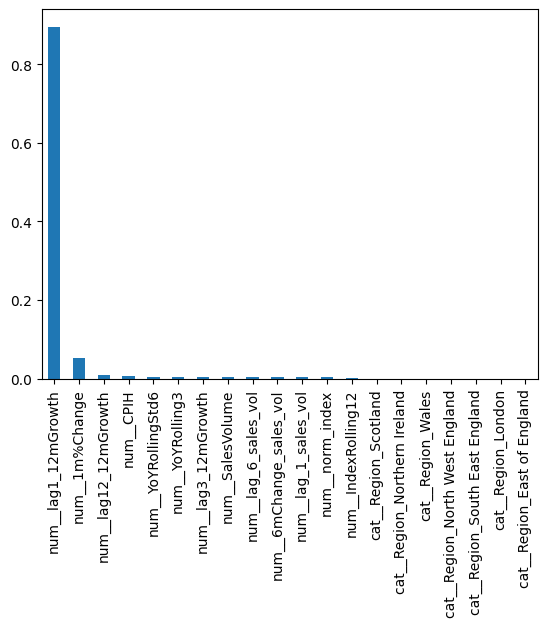

In [67]:
feat_imp.head(20).plot(kind="bar")

### Final analysis

- Results from the naïve benchmark and model-based feature importance both indicate that lagged housing growth is the dominant driver of predictive performance, consistent with strong autoregressive dynamics in the series.
- Sales volume provides additional explanatory power beyond persistence, capturing aspects of market activity.
- Regional fixed effects are comparatively less influential, suggesting that short-term temporal dynamics outweigh cross-sectional heterogeneity in this forecasting setup.